<a href="https://colab.research.google.com/github/Venky404/Google-Colab-Assignment/blob/main/Assignment_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving heart.csv to heart.csv


Q1. Load the Heart Disease dataset

In [2]:
# Import required libraries
import pandas as pd

# Load dataset
df = pd.read_csv('/content/heart.csv')

# Display first 10 rows
print("First 10 Rows:")
display(df.head(10))

# Shape
print("Shape of Dataset:", df.shape)

# Basic Information
print("\nDataset Information:")
df.info()

First 10 Rows:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


Shape of Dataset: (918, 12)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


Q2. Check Missing Values

In [3]:
print("Missing Values in Each Column:\n")
print(df.isnull().sum())

Missing Values in Each Column:

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


Q3. Check Duplicate Rows

In [4]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

if duplicates > 0:
    df = df.drop_duplicates()
    print("\nDuplicates Removed Successfully.")

print("New Shape:", df.shape)

Duplicate Rows: 0
New Shape: (918, 12)


Q4. Identify Invalid Values

In [5]:
chol_zero = (df["Cholesterol"] == 0).sum()
bp_zero = (df["RestingBP"] == 0).sum()

print("Rows with Cholesterol = 0 :", chol_zero)
print("Rows with RestingBP = 0 :", bp_zero)

Rows with Cholesterol = 0 : 172
Rows with RestingBP = 0 : 1


Q5. Clean Invalid Values

In [6]:
print("Before Cleaning\n")

print(df[["Cholesterol","RestingBP"]].describe())

# Calculate mean excluding zeros
chol_mean = df.loc[df["Cholesterol"] != 0, "Cholesterol"].mean()
bp_mean = df.loc[df["RestingBP"] != 0, "RestingBP"].mean()

# Replace invalid values
df["Cholesterol"] = df["Cholesterol"].replace(0, chol_mean)
df["RestingBP"] = df["RestingBP"].replace(0, bp_mean)

# Round values
df["Cholesterol"] = df["Cholesterol"].round(2)
df["RestingBP"] = df["RestingBP"].round(2)

print("\nAfter Cleaning\n")

print(df[["Cholesterol","RestingBP"]].describe())

Before Cleaning

       Cholesterol   RestingBP
count   918.000000  918.000000
mean    198.799564  132.396514
std     109.384145   18.514154
min       0.000000    0.000000
25%     173.250000  120.000000
50%     223.000000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000

After Cleaning

       Cholesterol   RestingBP
count   918.000000  918.000000
mean    244.636253  132.540893
std      53.318029   17.989932
min      85.000000   80.000000
25%     214.000000  120.000000
50%     244.640000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000


Q6. Plot Histograms

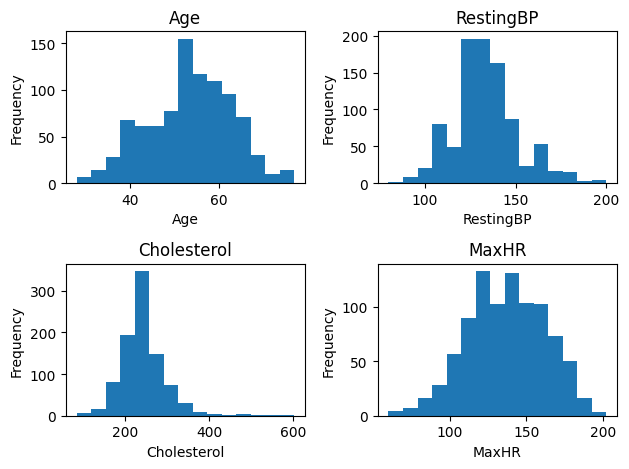

In [8]:
import matplotlib.pyplot as plt

def plot_hist(column, position):
    plt.subplot(2,2,position)
    plt.hist(df[column], bins=15)
    plt.title(column)
    plt.xlabel(column)
    plt.ylabel("Frequency")

plt.figure()

plot_hist("Age",1)
plot_hist("RestingBP",2)
plot_hist("Cholesterol",3)
plot_hist("MaxHR",4)

plt.tight_layout()
plt.show()

Q7. Numerical and Categorical Columns

In [9]:
numerical_columns = df.select_dtypes(include=['int64','float64']).columns

categorical_columns = df.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(list(numerical_columns))

print("\nCategorical Columns:")
print(list(categorical_columns))

Numerical Columns:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']

Categorical Columns:
['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


Q8. One-Hot Encoding

In [10]:
df_encoded = pd.get_dummies(df, columns=categorical_columns)

print("Shape after Encoding:")
print(df_encoded.shape)

print("\nFirst 5 Rows:")
display(df_encoded.head())

Shape after Encoding:
(918, 21)

First 5 Rows:


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138.0,214.0,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150.0,195.0,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True


Q9. Final Dataset Information

In [11]:
print("Final Shape:")
print(df_encoded.shape)

print("\nColumn Names:\n")

for column in df_encoded.columns:
    print(column)

Final Shape:
(918, 21)

Column Names:

Age
RestingBP
Cholesterol
FastingBS
MaxHR
Oldpeak
HeartDisease
Sex_F
Sex_M
ChestPainType_ASY
ChestPainType_ATA
ChestPainType_NAP
ChestPainType_TA
RestingECG_LVH
RestingECG_Normal
RestingECG_ST
ExerciseAngina_N
ExerciseAngina_Y
ST_Slope_Down
ST_Slope_Flat
ST_Slope_Up
